## Descripción del conjunto de datos

**Nombre del dataset:** Student Performance Factors
**Fuente:** Kaggle – Lai Ng
**Liga de acceso:** `https://www.kaggle.com/datasets/lainguyn123/student-performance-factors`
**Fecha de consulta:** 15 de agosto de 2026
**Última actualización:** Kaggle reporta actualmente que el conjunto de datos fue actualizado hace aproximadamente dos años.

El conjunto de datos Student Performance Factors contiene información relacionada con diferentes factores que pueden influir en el desempeño académico de los estudiantes. Incluye variables relacionadas con hábitos de estudio, asistencia, participación de los padres, acceso a recursos, sueño, motivación, ingresos familiares, calidad docente, actividad física y otros aspectos personales y escolares.

Cada registro representa a un estudiante y contiene sus características académicas, personales y familiares, además del resultado obtenido en su examen final.

La variable que podría utilizarse como objetivo es **Exam_Score**, ya que representa el puntaje final obtenido por cada estudiante. Debido a que esta variable es numérica, se podría plantear un problema de **aprendizaje supervisado de regresión**, donde el objetivo sería predecir el puntaje de examen a partir del resto de las características.

Un modelo construido con estos datos podría utilizarse para analizar qué factores tienen mayor relación con el desempeño académico y estimar el posible resultado de un estudiante. Esto podría ser útil para identificar estudiantes que podrían requerir apoyo adicional y comprender mejor qué condiciones están asociadas con un mejor rendimiento escolar.


In [4]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
import numpy as np
import zipfile

# Descomprimir el archivo
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# Cargar el CSV
df = pd.read_csv('/content/dataset/StudentPerformanceFactors.csv')

df.head()

Saving archive.zip to archive.zip


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nNombres de las columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores únicos por columna:")
print(df.nunique())

# Estadísticas descriptivas
display(df.describe(include='all').T)

# Muestra de registros
display(df.head(10))

Dimensiones del dataset:
(6607, 20)

Nombres de las columnas:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Tipos de datos:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Ac

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


## Interpretación del estado inicial del dataset

El conjunto de datos presenta inicialmente una estructura adecuada para realizar análisis y posteriormente desarrollar un modelo de aprendizaje automático. Cuenta con 6,607 registros y 20 variables, combinando características numéricas y categóricas relacionadas con el desempeño de los estudiantes.

No se encontraron registros duplicados y la mayoría de las variables se encuentran completas. Sin embargo, existen valores faltantes en las variables Teacher_Quality, Parental_Education_Level y Distance_from_Home. Estos representan una proporción pequeña del conjunto de datos, por lo que pueden tratarse posteriormente sin eliminar una cantidad significativa de información.

Los tipos de datos corresponden en general con la naturaleza de cada variable y las categorías presentan valores consistentes. No obstante, durante el análisis de los valores numéricos se identificaron algunos posibles valores extremos, además de un Exam_Score de 101, el cual debe revisarse debido a que supera el rango esperado de una calificación de 0 a 100.

En general, el dataset presenta una buena calidad inicial, pero requiere algunas operaciones de limpieza antes de utilizarse en un modelo predictivo.


In [6]:
'Valores Faltantes'
faltantes = pd.DataFrame({
    'Valores_faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})

display(faltantes[faltantes['Valores_faltantes'] > 0])

,Valores_faltantes,Porcentaje
Teacher_Quality,78,1.18
Parental_Education_Level,90,1.36
Distance_from_Home,67,1.01


In [7]:
'Duplicados'
print("Número de registros duplicados:", df.duplicated().sum())

Número de registros duplicados: 0


In [8]:
'Revisar categorías'
columnas_categoricas = df.select_dtypes(include='object').columns

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(df[columna].unique())


Parental_Involvement:
['Low' 'Medium' 'High']

Access_to_Resources:
['High' 'Medium' 'Low']

Extracurricular_Activities:
['No' 'Yes']

Motivation_Level:
['Low' 'Medium' 'High']

Internet_Access:
['Yes' 'No']

Family_Income:
['Low' 'Medium' 'High']

Teacher_Quality:
['Medium' 'High' 'Low' nan]

School_Type:
['Public' 'Private']

Peer_Influence:
['Positive' 'Negative' 'Neutral']

Learning_Disabilities:
['No' 'Yes']

Parental_Education_Level:
['High School' 'College' 'Postgraduate' nan]

Distance_from_Home:
['Near' 'Moderate' 'Far' nan]

Gender:
['Male' 'Female']


In [9]:
'Buscar espacios adicionales'
for columna in columnas_categoricas:
    espacios = (
        df[columna]
        .dropna()
        .astype(str)
        .ne(df[columna].dropna().astype(str).str.strip())
        .sum()
    )

    print(columna, ":", espacios)

Parental_Involvement : 0
Access_to_Resources : 0
Extracurricular_Activities : 0
Motivation_Level : 0
Internet_Access : 0
Family_Income : 0
Teacher_Quality : 0
School_Type : 0
Peer_Influence : 0
Learning_Disabilities : 0
Parental_Education_Level : 0
Distance_from_Home : 0
Gender : 0


In [10]:
'detectar valores extremos con IQR'
columnas_numericas = df.select_dtypes(include=np.number).columns

resultados_outliers = []

for columna in columnas_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    resultados_outliers.append({
        'Variable': columna,
        'Límite inferior': limite_inferior,
        'Límite superior': limite_superior,
        'Cantidad de outliers': len(outliers)
    })

outliers_df = pd.DataFrame(resultados_outliers)
display(outliers_df)

'Exam_Score = 101'
df[df['Exam_Score'] > 100]

,Variable,Límite inferior,Límite superior,Cantidad de outliers
0,Hours_Studied,4.0,36.0,43
1,Attendance,40.0,120.0,0
2,Sleep_Hours,3.0,11.0,0
3,Previous_Scores,25.5,125.5,0
4,Tutoring_Sessions,-0.5,3.5,430
5,Physical_Activity,-1.0,7.0,0
6,Exam_Score,59.0,75.0,104


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


| Problema detectado             | Variable afectada          | Evidencia                                       | Tratamiento propuesto                                                                           |
| ------------------------------ | -------------------------- | ----------------------------------------------- | ----------------------------------------------------------------------------------------------- |
| Valores faltantes              | `Teacher_Quality`          | 78 valores faltantes (1.18%)                    | Imputar con la categoría más frecuente                                                          |
| Valores faltantes              | `Parental_Education_Level` | 90 valores faltantes (1.36%)                    | Imputar con la categoría más frecuente                                                          |
| Valores faltantes              | `Distance_from_Home`       | 67 valores faltantes (1.01%)                    | Imputar con la categoría más frecuente                                                          |
| Valor fuera del rango esperado | `Exam_Score`               | Se encontró un registro con valor 101           | Eliminar el registro o considerarlo como dato inválido, ya que supera el máximo esperado de 100 |
| Posibles valores extremos      | `Hours_Studied`            | 43 registros fuera del rango IQR de 4 a 36      | Revisar los registros antes de eliminarlos, ya que pueden ser valores reales                    |
| Posibles valores extremos      | `Tutoring_Sessions`        | 430 registros fuera del rango IQR de -0.5 a 3.5 | Mantener inicialmente, ya que valores de 4 o más sesiones son posibles                          |
| Posibles valores extremos      | `Exam_Score`               | 104 registros fuera del rango IQR de 59 a 75    | No eliminar automáticamente; revisar únicamente valores fuera del rango válido de calificación  |

El análisis de calidad muestra que el dataset se encuentra en buenas condiciones generales. No se identificaron registros duplicados, espacios adicionales ni inconsistencias evidentes en las variables categóricas. Los principales problemas encontrados corresponden a valores faltantes en tres variables categóricas y algunos valores extremos detectados mediante el método IQR. Sin embargo, no todos los valores extremos representan errores, ya que algunos pueden corresponder a casos reales. El hallazgo más relevante es un valor de 101 en Exam_Score, el cual se encuentra fuera del rango esperado y deberá corregirse antes de construir el modelo.


In [3]:
from google.colab import files
import pandas as pd
import zipfile

# Subir el archivo
uploaded = files.upload()

# Obtener automáticamente el nombre del ZIP subido
nombre_zip = next(iter(uploaded))

# Descomprimir
with zipfile.ZipFile(nombre_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# Cargar dataset
df = pd.read_csv('/content/dataset/StudentPerformanceFactors.csv')

print("Dataset cargado correctamente:", df.shape)
df.head()

Saving archive.zip to archive.zip
Dataset cargado correctamente: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
df_limpio = df.copy()

In [8]:
'Estandarización de nombres'
df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print(df_limpio.columns.tolist())

['hours_studied', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'sleep_hours', 'previous_scores', 'motivation_level', 'internet_access', 'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'physical_activity', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender', 'exam_score']


In [9]:
'Eliminar duplicados'
filas_antes = len(df_limpio)

df_limpio = df_limpio.drop_duplicates()

filas_despues = len(df_limpio)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Duplicados eliminados:", filas_antes - filas_despues)

Filas antes: 6607
Filas después: 6607
Duplicados eliminados: 0


In [10]:
'Estandarizar las categorías'
columnas_categoricas = df_limpio.select_dtypes(include='object').columns

for columna in columnas_categoricas:
    df_limpio[columna] = (
        df_limpio[columna]
        .str.strip()
        .str.title()
    )

print("Categorías estandarizadas correctamente.")

Categorías estandarizadas correctamente.


In [11]:
'Verificamos que sigan constantes'
for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(df_limpio[columna].unique())


parental_involvement:
['Low' 'Medium' 'High']

access_to_resources:
['High' 'Medium' 'Low']

extracurricular_activities:
['No' 'Yes']

motivation_level:
['Low' 'Medium' 'High']

internet_access:
['Yes' 'No']

family_income:
['Low' 'Medium' 'High']

teacher_quality:
['Medium' 'High' 'Low' nan]

school_type:
['Public' 'Private']

peer_influence:
['Positive' 'Negative' 'Neutral']

learning_disabilities:
['No' 'Yes']

parental_education_level:
['High School' 'College' 'Postgraduate' nan]

distance_from_home:
['Near' 'Moderate' 'Far' nan]

gender:
['Male' 'Female']


In [12]:
'Tratamiento de valores faltantes mediante imputación por moda'
columnas_con_faltantes = [
    'teacher_quality',
    'parental_education_level',
    'distance_from_home'
]

for columna in columnas_con_faltantes:
    moda = df_limpio[columna].mode()[0]
    print(columna, "→", moda)

teacher_quality → Medium
parental_education_level → High School
distance_from_home → Near


In [13]:
for columna in columnas_con_faltantes:
    moda = df_limpio[columna].mode()[0]
    df_limpio[columna] = df_limpio[columna].fillna(moda)

print("Valores faltantes después de la imputación:")
print(df_limpio[columnas_con_faltantes].isnull().sum())

Valores faltantes después de la imputación:
teacher_quality             0
parental_education_level    0
distance_from_home          0
dtype: int64


Se reemplazaron los valores faltantes de las variables categóricas utilizando la moda de cada columna. Después de la imputación, las tres variables quedaron sin valores faltantes y no fue necesario eliminar registros.

In [14]:
'Verificamos el registro de exam_score > 100'
df_limpio[df_limpio['exam_score'] > 100]

,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [15]:
'Eliminamos'
filas_antes = len(df_limpio)

df_limpio = df_limpio[
    df_limpio['exam_score'].between(0, 100)
].copy()

print("Registros eliminados:", filas_antes - len(df_limpio))
print("Dimensiones finales:", df_limpio.shape)

Registros eliminados: 1
Dimensiones finales: (6606, 20)


Se identificó un registro con un puntaje de examen igual a 101, valor que supera el rango esperado de 0 a 100. Debido a que exam_score será la posible variable objetivo, se eliminó únicamente este registro en lugar de modificar su valor artificialmente.

In [16]:
'Conversión de variables categóricas'
columnas_categoricas = df_limpio.select_dtypes(include='object').columns

for columna in columnas_categoricas:
    df_limpio[columna] = df_limpio[columna].astype('category')

df_limpio.dtypes

,0
hours_studied,int64
attendance,int64
parental_involvement,category
access_to_resources,category
extracurricular_activities,category
sleep_hours,int64
previous_scores,int64
motivation_level,category
internet_access,category
tutoring_sessions,int64


Las variables categóricas fueron convertidas del tipo object al tipo category, ya que representan grupos discretos y no texto libre. Esta conversión permite identificar correctamente la naturaleza de estas variables y facilita su posterior codificación para modelos de aprendizaje automático.

In [17]:
'Verificación final del proceso de limpieza'
print("Dimensiones finales:", df_limpio.shape)
print("Valores faltantes totales:", df_limpio.isnull().sum().sum())
print("Registros duplicados:", df_limpio.duplicated().sum())

print("\nRango de exam_score:")
print("Mínimo:", df_limpio['exam_score'].min())
print("Máximo:", df_limpio['exam_score'].max())

Dimensiones finales: (6606, 20)
Valores faltantes totales: 0
Registros duplicados: 0

Rango de exam_score:
Mínimo: 55
Máximo: 100


Después del proceso de limpieza, el conjunto de datos quedó conformado por 6,606 registros y 20 variables. No se encontraron valores faltantes ni registros duplicados y la variable exam_score quedó dentro del rango válido de 0 a 100. Se eliminó únicamente un registro debido a que contenía un puntaje imposible de 101.

In [18]:
'Analizar exam_score como variable de interés'
print(df_limpio['exam_score'].describe())

print("\nMediana:", df_limpio['exam_score'].median())
print("Moda:", df_limpio['exam_score'].mode()[0])
print("Varianza:", df_limpio['exam_score'].var())
print("Asimetría:", df_limpio['exam_score'].skew())


count    6606.000000
mean       67.230548
std         3.868502
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: exam_score, dtype: float64

Mediana: 67.0
Moda: 68
Varianza: 14.965310433956976
Asimetría: 1.5764938875525518


La variable exam_score presenta una media de 67.23, una mediana de 67 y una moda de 68, lo que indica que la mayor parte de los puntajes se concentra alrededor de estos valores. La desviación estándar de 3.87 muestra una dispersión relativamente baja. La asimetría positiva de 1.58 indica que existen algunos puntajes altos poco frecuentes que extienden la distribución hacia la derecha. Aunque estos valores pueden considerarse atípicos estadísticamente, se mantienen debido a que se encuentran dentro del rango válido de 0 a 100.

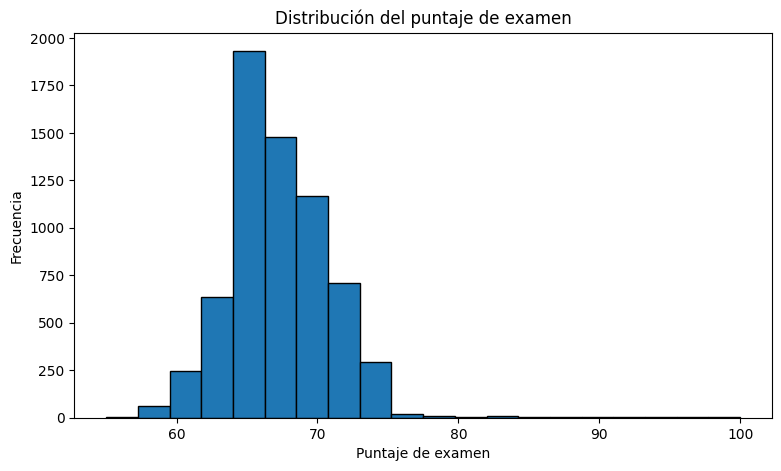

In [19]:
'Distribución de Exam_Score'
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    df_limpio['exam_score'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribución del puntaje de examen')
plt.xlabel('Puntaje de examen')
plt.ylabel('Frecuencia')

plt.show()

La distribución de exam_score se concentra principalmente entre 63 y 73 puntos, con mayor frecuencia alrededor de 65 a 68. La gráfica presenta una cola hacia la derecha, lo que indica una asimetría positiva provocada por algunos puntajes altos poco frecuentes. Aunque existen valores atípicos estadísticos, estos se encuentran dentro del rango válido de 0 a 100, por lo que se conservaron para el análisis.

In [20]:
'Análisis de Previous_Scores'
print(df_limpio['previous_scores'].describe())

print("\nMediana:", df_limpio['previous_scores'].median())
print("Moda:", df_limpio['previous_scores'].mode()[0])
print("Asimetría:", df_limpio['previous_scores'].skew())

count    6606.000000
mean       75.067817
std        14.399184
min        50.000000
25%        63.000000
50%        75.000000
75%        88.000000
max       100.000000
Name: previous_scores, dtype: float64

Mediana: 75.0
Moda: 66
Asimetría: -0.003464302027649063


La variable previous_scores presenta una media de 75.07 y una mediana de 75, valores prácticamente iguales, lo que sugiere una distribución equilibrada. La asimetría de -0.003 es muy cercana a cero, indicando que la distribución es prácticamente simétrica. Los puntajes se encuentran entre 50 y 100 y no se identifican valores atípicos mediante el criterio IQR, por lo que no se requiere tratamiento adicional.

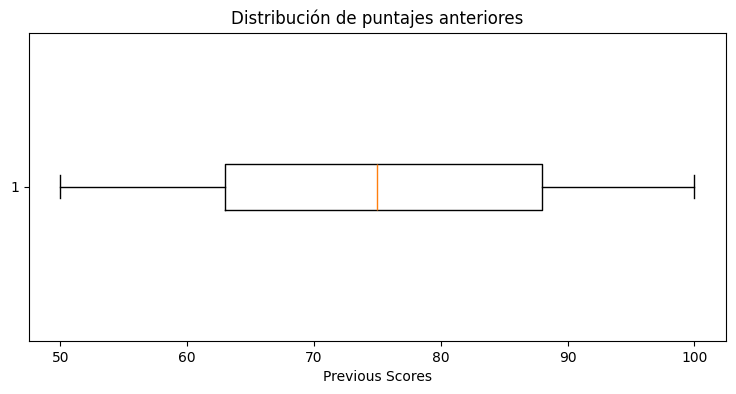

In [21]:
'Distribución y valores atípicos de Previous_Scores'
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))

plt.boxplot(
    df_limpio['previous_scores'],
    vert=False
)

plt.title('Distribución de puntajes anteriores')
plt.xlabel('Previous Scores')

plt.show()

El diagrama de caja de previous_scores muestra una distribución equilibrada, con una mediana cercana a 75 y sin valores atípicos visibles. Los puntajes se encuentran entre 50 y 100, por lo que no se identifican valores imposibles ni se requiere algún tratamiento adicional.

In [22]:
'Análisis de Hours_Studied'
print(df_limpio['hours_studied'].describe())

print("\nMediana:", df_limpio['hours_studied'].median())
print("Moda:", df_limpio['hours_studied'].mode()[0])
print("Asimetría:", df_limpio['hours_studied'].skew())

count    6606.000000
mean       19.974266
std         5.990424
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: hours_studied, dtype: float64

Mediana: 20.0
Moda: 20
Asimetría: 0.013790593436313371


La variable hours_studied presenta una media de 19.97 horas, una mediana y moda de 20 horas. La asimetría de 0.014 es muy cercana a cero, lo que indica una distribución prácticamente simétrica. Mediante el criterio IQR se consideran atípicos los valores menores a 4 y mayores a 36 horas. Sin embargo, estos valores siguen siendo posibles en la realidad, por lo que se conservaron.

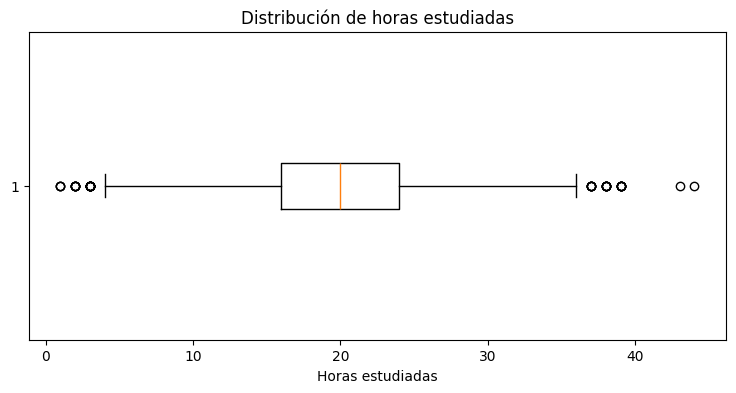

In [23]:
plt.figure(figsize=(9, 4))

plt.boxplot(
    df_limpio['hours_studied'],
    vert=False
)

plt.title('Distribución de horas estudiadas')
plt.xlabel('Horas estudiadas')

plt.show()

El diagrama de caja de hours_studied muestra que la mayoría de los estudiantes se concentra alrededor de 20 horas de estudio. Se identifican valores atípicos por debajo de 4 horas y por encima de 36 horas según el criterio IQR. Sin embargo, estos valores siguen siendo posibles en un contexto real, por lo que se conservaron y no se consideraron errores del dataset.

In [24]:
'Análisis de Motivation_Level'
print(df_limpio['motivation_level'].value_counts())

print("\nPorcentajes:")
print(
    df_limpio['motivation_level']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

motivation_level
Medium    3351
Low       1936
High      1319
Name: count, dtype: int64

Porcentajes:
motivation_level
Medium    50.73
Low       29.31
High      19.97
Name: proportion, dtype: float64


La variable motivation_level se distribuye principalmente en la categoría Medium, que representa aproximadamente el 50.73% de los estudiantes. La categoría Low concentra el 29.31% y High el 19.97%. No se identifican categorías inconsistentes ni poco representadas, por lo que no se requiere tratamiento adicional.

In [25]:
'Análisis de Parental_Involvement'
print(df_limpio['parental_involvement'].value_counts())

print("\nPorcentajes:")
print(
    df_limpio['parental_involvement']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

parental_involvement
Medium    3362
High      1908
Low       1336
Name: count, dtype: int64

Porcentajes:
parental_involvement
Medium    50.89
High      28.88
Low       20.22
Name: proportion, dtype: float64


La variable parental_involvement se concentra principalmente en la categoría Medium, con 50.89% de los estudiantes. La categoría High representa 28.88% y Low el 20.22%. No se identifican categorías inconsistentes ni poco frecuentes, por lo que la variable puede conservarse sin modificaciones adicionales.

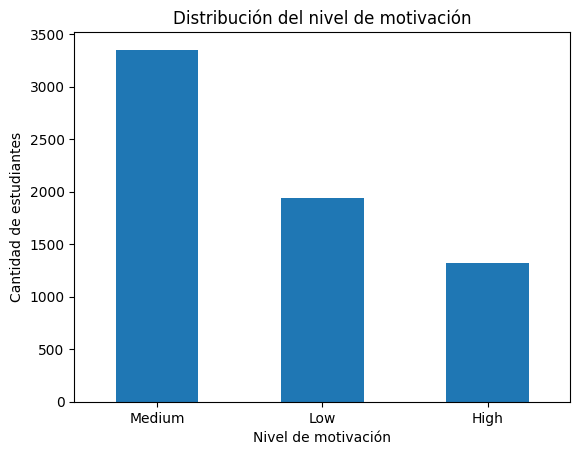

In [26]:
'Gráfica de barras de motivation_level'
df_limpio['motivation_level'].value_counts().plot(kind='bar')

plt.title('Distribución del nivel de motivación')
plt.xlabel('Nivel de motivación')
plt.ylabel('Cantidad de estudiantes')
plt.xticks(rotation=0)

plt.show()

La gráfica muestra que el nivel de motivación más frecuente es Medium, con aproximadamente la mitad de los estudiantes. Le sigue Low y, finalmente, High. Aunque las categorías no se encuentran distribuidas de manera uniforme, todas cuentan con una cantidad suficiente de observaciones y no se identifican categorías poco comunes o inconsistentes.

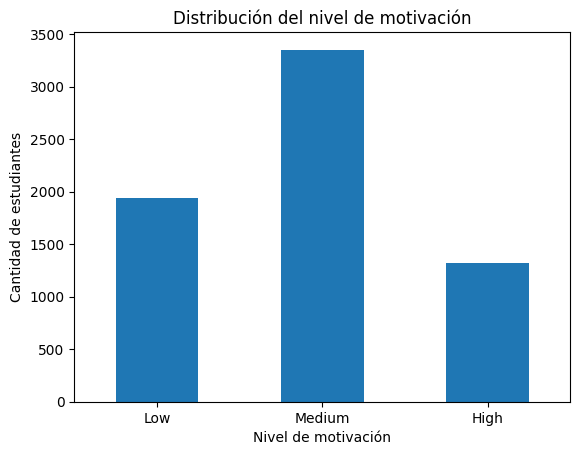

In [27]:
'Ajuste de orden mas natural'

orden = ['Low', 'Medium', 'High']

df_limpio['motivation_level'].value_counts().reindex(orden).plot(kind='bar')

plt.title('Distribución del nivel de motivación')
plt.xlabel('Nivel de motivación')
plt.ylabel('Cantidad de estudiantes')
plt.xticks(rotation=0)

plt.show()

La distribución de motivation_level muestra que la categoría Medium es la más frecuente, seguida por Low y High. La variable presenta un orden natural entre sus categorías, lo que permitirá posteriormente utilizar una codificación ordinal sin perder su relación jerárquica.

In [28]:
'Codificación One-Hot de School_Type'
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(
    drop='first',
    sparse_output=False
)

school_encoded = onehot.fit_transform(
    df_limpio[['school_type']]
)

print("Categorías originales:")
print(df_limpio['school_type'].unique())

print("\nNuevas variables:")
print(onehot.get_feature_names_out(['school_type']))

print("\nPrimeros valores transformados:")
print(school_encoded[:10])

Categorías originales:
['Public', 'Private']
Categories (2, object): ['Private', 'Public']

Nuevas variables:
['school_type_Public']

Primeros valores transformados:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]]


Se aplicó One-Hot Encoding a school_type porque es una variable nominal y sus categorías no tienen un orden natural. Al utilizar drop='first', se conserva una sola variable binaria, donde 1 representa Public y 0 representa Private. Esto evita redundancia entre las categorías.

In [29]:
'Codificación ordinal de Motivation_Level'
from sklearn.preprocessing import OrdinalEncoder

ordinal = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High']]
)

motivation_encoded = ordinal.fit_transform(
    df_limpio[['motivation_level']]
)

print("Categorías originales:")
print(df_limpio['motivation_level'].unique())

print("\nOrden utilizado:")
print("Low = 0, Medium = 1, High = 2")

print("\nPrimeros valores transformados:")
print(motivation_encoded[:10])

Categorías originales:
['Low', 'Medium', 'High']
Categories (3, object): ['High', 'Low', 'Medium']

Orden utilizado:
Low = 0, Medium = 1, High = 2

Primeros valores transformados:
[[0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [2.]
 [1.]]


Se aplicó codificación ordinal a motivation_level porque sus categorías poseen un orden natural: Low, Medium y High. Se asignaron los valores 0, 1 y 2 respectivamente, permitiendo conservar la jerarquía existente entre las categorías. A diferencia de una variable nominal, aquí la representación numérica sí debe reflejar el orden de los niveles.

In [30]:
'Escalamiento de variables numéricas con StandardScaler'
from sklearn.preprocessing import StandardScaler
import pandas as pd

variables_numericas = ['hours_studied', 'previous_scores']

scaler = StandardScaler()

valores_escalados = scaler.fit_transform(
    df_limpio[variables_numericas]
)

comparacion = df_limpio[variables_numericas].head().reset_index(drop=True)

comparacion['hours_studied_scaled'] = valores_escalados[:5, 0]
comparacion['previous_scores_scaled'] = valores_escalados[:5, 1]

display(comparacion)


,hours_studied,previous_scores,hours_studied_scaled,previous_scores_scaled
0,23,73,0.505133,-0.143617
1,19,59,-0.162650,-1.115968
2,24,91,0.672079,1.106548
3,29,98,1.506808,1.592723
4,19,65,-0.162650,-0.699247


Se aplicó StandardScaler a las variables hours_studied y previous_scores. Después de la transformación, los valores quedan expresados en función de su distancia respecto a la media, con una media cercana a 0 y una desviación estándar cercana a 1. El escalamiento no modifica el orden ni las relaciones entre las observaciones, sino únicamente la escala en la que se representan. Esto es importante para algoritmos sensibles a las magnitudes o distancias, ya que evita que una variable tenga mayor influencia únicamente por manejar valores numéricos más grandes.

In [31]:
'Organización reproducible del preprocesamiento con ColumnTransformer'
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

variables_numericas = [
    'hours_studied',
    'previous_scores'
]

variables_nominales = [
    'school_type'
]

variables_ordinales = [
    'motivation_level'
]

preprocesador = ColumnTransformer(
    transformers=[
        (
            'numericas',
            StandardScaler(),
            variables_numericas
        ),
        (
            'nominales',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            variables_nominales
        ),
        (
            'ordinales',
            OrdinalEncoder(
                categories=[
                    ['Low', 'Medium', 'High']
                ]
            ),
            variables_ordinales
        )
    ]
)

preprocesador

ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                 ['hours_studied', 'previous_scores']),
                                ('nominales',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['school_type']),
                                ('ordinales',
                                 OrdinalEncoder(categories=[['Low', 'Medium',
                                                             'High']]),
                                 ['motivation_level'])])

Se utilizó ColumnTransformer para organizar de manera reproducible las transformaciones aplicadas a diferentes tipos de variables. Las variables numéricas se estandarizaron mediante StandardScaler, la variable nominal school_type se transformó mediante One-Hot Encoding y la variable ordinal motivation_level mediante codificación ordinal. Esta estructura permite aplicar automáticamente el tratamiento correspondiente a cada grupo de variables.

In [32]:
X_ejemplo = df_limpio[
    [
        'hours_studied',
        'previous_scores',
        'school_type',
        'motivation_level'
    ]
]

X_transformado = preprocesador.fit_transform(X_ejemplo)

print("Dimensiones originales:", X_ejemplo.shape)
print("Dimensiones transformadas:", X_transformado.shape)

print("\nPrimeros 5 registros transformados:")
print(X_transformado[:5])

Dimensiones originales: (6606, 4)
Dimensiones transformadas: (6606, 4)

Primeros 5 registros transformados:
[[ 0.50513338 -0.14361742  1.          0.        ]
 [-0.16264951 -1.11596832  1.          0.        ]
 [ 0.67207911  1.10654803  1.          1.        ]
 [ 1.50680772  1.59272348  1.          1.        ]
 [-0.16264951 -0.69924651  1.          1.        ]]


En esta actividad, las transformaciones se aplicaron al conjunto completo únicamente con fines exploratorios y demostrativos. Sin embargo, durante una etapa posterior de modelado, el escalamiento, la codificación y cualquier técnica de imputación deberán ajustarse únicamente con los datos de entrenamiento. Posteriormente, las transformaciones aprendidas se aplicarán al conjunto de prueba. Esto evita la fuga de información o data leakage, ya que los datos de prueba no deben influir en la preparación ni entrenamiento del modelo.

In [33]:
'Tabla de estado inicial vs. final'
resumen_transformaciones = pd.DataFrame({
    'Elemento': [
        'Número de registros',
        'Número de variables',
        'Valores faltantes',
        'Registros duplicados',
        'Variables categóricas transformadas',
        'Variables numéricas escaladas'
    ],
    'Estado inicial': [
        6607,
        20,
        235,
        0,
        'Sin codificación',
        'Sin escalamiento'
    ],
    'Estado final': [
        6606,
        20,
        0,
        0,
        'school_type (One-Hot) y motivation_level (Ordinal)',
        'hours_studied y previous_scores (StandardScaler)'
    ]
})

display(resumen_transformaciones)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6606
1,Número de variables,20,20
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,Sin codificación,school_type (One-Hot) y motivation_level (Ordi...
5,Variables numéricas escaladas,Sin escalamiento,hours_studied y previous_scores (StandardScaler)


La comparación muestra que el proceso de limpieza redujo el conjunto únicamente en un registro debido a un valor imposible, mientras que se conservaron las 20 variables. Los 235 valores faltantes fueron tratados y no existían registros duplicados. Además, se prepararon variables categóricas y numéricas seleccionadas mediante técnicas de codificación y escalamiento, manteniendo la variable objetivo exam_score sin transformar.

In [34]:
'Creación del dataset preparado'
df_preparado = df_limpio.drop(
    columns=[
        'hours_studied',
        'previous_scores',
        'school_type',
        'motivation_level'
    ]
).copy()

# Variables numéricas escaladas
df_preparado['hours_studied_scaled'] = valores_escalados[:, 0]
df_preparado['previous_scores_scaled'] = valores_escalados[:, 1]

# Variable nominal codificada con One-Hot
df_preparado['school_type_public'] = school_encoded.ravel().astype(int)

# Variable ordinal codificada
df_preparado['motivation_level_encoded'] = motivation_encoded.ravel().astype(int)

print("Dimensiones del dataset preparado:", df_preparado.shape)
print("Variable objetivo presente:", 'exam_score' in df_preparado.columns)

df_preparado.head()

Dimensiones del dataset preparado: (6606, 20)
Variable objetivo presente: True


,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,internet_access,tutoring_sessions,family_income,teacher_quality,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score,hours_studied_scaled,previous_scores_scaled,school_type_public,motivation_level_encoded
0,84,Low,High,No,7,Yes,0,Low,Medium,Positive,3,No,High School,Near,Male,67,0.505133,-0.143617,1,0
1,64,Low,Medium,No,8,Yes,2,Medium,Medium,Negative,4,No,College,Moderate,Female,61,-0.162650,-1.115968,1,0
2,98,Medium,Medium,Yes,7,Yes,2,Medium,Medium,Neutral,4,No,Postgraduate,Near,Male,74,0.672079,1.106548,1,1
3,89,Low,Medium,Yes,8,Yes,1,Medium,Medium,Negative,4,No,High School,Moderate,Male,71,1.506808,1.592723,1,1
4,92,Medium,Medium,Yes,6,Yes,3,Medium,High,Neutral,4,No,College,Near,Female,70,-0.162650,-0.699247,1,1


Se creó una versión preparada del dataset conservando las 20 variables. Las variables seleccionadas para codificación y escalamiento fueron sustituidas por sus representaciones transformadas, mientras que exam_score se mantuvo sin modificar como posible variable objetivo para una etapa posterior de modelado.

In [35]:
'Exportación y verificación del dataset preparado'
ruta_salida = '/content/StudentPerformanceFactors_preparado.csv'

df_preparado.to_csv(
    ruta_salida,
    index=False
)

print("Archivo exportado correctamente.")

Archivo exportado correctamente.


In [36]:
df_verificacion = pd.read_csv(
    '/content/StudentPerformanceFactors_preparado.csv'
)

print("Archivo cargado correctamente.")
print("Dimensiones:", df_verificacion.shape)
print("Valores faltantes:", df_verificacion.isnull().sum().sum())
print("Duplicados:", df_verificacion.duplicated().sum())
print("Variable objetivo presente:", 'exam_score' in df_verificacion.columns)

display(df_verificacion.head())

Archivo cargado correctamente.
Dimensiones: (6606, 20)
Valores faltantes: 0
Duplicados: 0
Variable objetivo presente: True


,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,internet_access,tutoring_sessions,family_income,teacher_quality,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score,hours_studied_scaled,previous_scores_scaled,school_type_public,motivation_level_encoded
0,84,Low,High,No,7,Yes,0,Low,Medium,Positive,3,No,High School,Near,Male,67,0.505133,-0.143617,1,0
1,64,Low,Medium,No,8,Yes,2,Medium,Medium,Negative,4,No,College,Moderate,Female,61,-0.162650,-1.115968,1,0
2,98,Medium,Medium,Yes,7,Yes,2,Medium,Medium,Neutral,4,No,Postgraduate,Near,Male,74,0.672079,1.106548,1,1
3,89,Low,Medium,Yes,8,Yes,1,Medium,Medium,Negative,4,No,High School,Moderate,Male,71,1.506808,1.592723,1,1
4,92,Medium,Medium,Yes,6,Yes,3,Medium,High,Neutral,4,No,College,Near,Female,70,-0.162650,-0.699247,1,1


El dataset preparado fue exportado correctamente en formato CSV y posteriormente se volvió a cargar para verificar su integridad. La versión final conserva 6,606 registros y 20 variables, no contiene valores faltantes ni registros duplicados y mantiene exam_score como posible variable objetivo. Esto confirma que el archivo puede utilizarse posteriormente sin errores derivados del proceso de limpieza.

En general, el dataset ya venía bastante bien estructurado, pero sí fue necesario hacer algunos ajustes antes de dejarlo listo para trabajar con un modelo. Los principales problemas fueron los valores faltantes en algunas variables categóricas y un valor de 101 en `exam_score`, que claramente estaba fuera del rango esperado. Los faltantes se completaron usando la moda y el registro con 101 fue eliminado, mientras que los valores atípicos que todavía eran posibles en un contexto real se conservaron.

También se prepararon algunas variables para una futura etapa de modelado. `school_type` se transformó con One-Hot Encoding porque sus categorías no tienen un orden, mientras que `motivation_level` se codificó de forma ordinal respetando el orden Low, Medium y High. Por otro lado, `hours_studied` y `previous_scores` se escalaron con StandardScaler para que pudieran compararse en una misma escala sin perder la información original.

Después de todo el proceso, el dataset quedó con 6,606 registros, 20 variables, sin valores faltantes ni duplicados y con `exam_score` conservada como posible variable objetivo. Aun así, todavía hay otras variables categóricas que tendrían que transformarse si se quisiera utilizar todo el dataset en un modelo. El siguiente paso sería separar los datos en entrenamiento y prueba y aplicar el preprocesamiento únicamente con los datos de entrenamiento para evitar fuga de información antes de comenzar a entrenar y evaluar un modelo de regresión.
